In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("./Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df=df.select_dtypes(include=['float64','int64'])
df

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [6]:
print(df.isnull().sum())

price        0
area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
dtype: int64


In [7]:
def outlier_remover(a1,a2,b1,b2,c1,c2,d1,d2,e1,e2,f1,f2,df):
    new_df=df[(df['price']>a1)&(df['price']<a2)&
                (df['area']>b1)&(df['area']<b2)&
                (df['bedrooms']>c1)&(df['bedrooms']<c2)&
                (df['bathrooms']>d1)&(df['bathrooms']<d2)&
                (df['stories'] >e1)&(df['stories']<e2)&
                (df['parking'] >f1)&(df['parking']<f2)]
    return new_df

In [8]:
#range=[Q1−1.5⋅IQR,Q3+1.5⋅IQR]

q1=df[['price','area','bedrooms','bathrooms','stories','parking']].quantile(0.25)
q3=df[['price','area','bedrooms','bathrooms','stories','parking']].quantile(0.75)

price_a=q1.price-1.5*(q3.price-q1.price)
price_b=q3.price+1.5*(q3.price-q1.price)

area_a=q1.area-1.5*(q3.area-q1.area)
area_b=q3.area+1.5*(q3.area-q1.area)

bedrooms_a=q1.bedrooms-1.5*(q3.bedrooms-q1.bedrooms)
bedrooms_b=q3.bedrooms+1.5*(q3.bedrooms-q1.bedrooms)

bathrooms_a=q1.bathrooms-1.5*(q3.bathrooms-q1.bathrooms)
bathrooms_b=q3.bathrooms+1.5*(q3.bathrooms-q1.bathrooms)

stories_a=q1.stories-1.5*(q3.stories-q1.stories)
stories_b=q3.stories+1.5*(q3.stories-q1.stories)

parking_a=q1.parking-1.5*(q3.parking-q1.parking)
parking_b=q3.parking+1.5*(q3.parking-q1.parking)

df2=outlier_remover(price_a,price_b,area_a,area_b,bedrooms_a,bedrooms_b,bathrooms_a,bathrooms_b,stories_a,stories_b,parking_a,parking_b,df)
df2

,price,area,bedrooms,bathrooms,stories,parking
15,9100000,6000,4,1,2,2
16,9100000,6600,4,2,2,1
18,8890000,4600,3,2,2,2
19,8855000,6420,3,2,2,1
20,8750000,4320,3,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


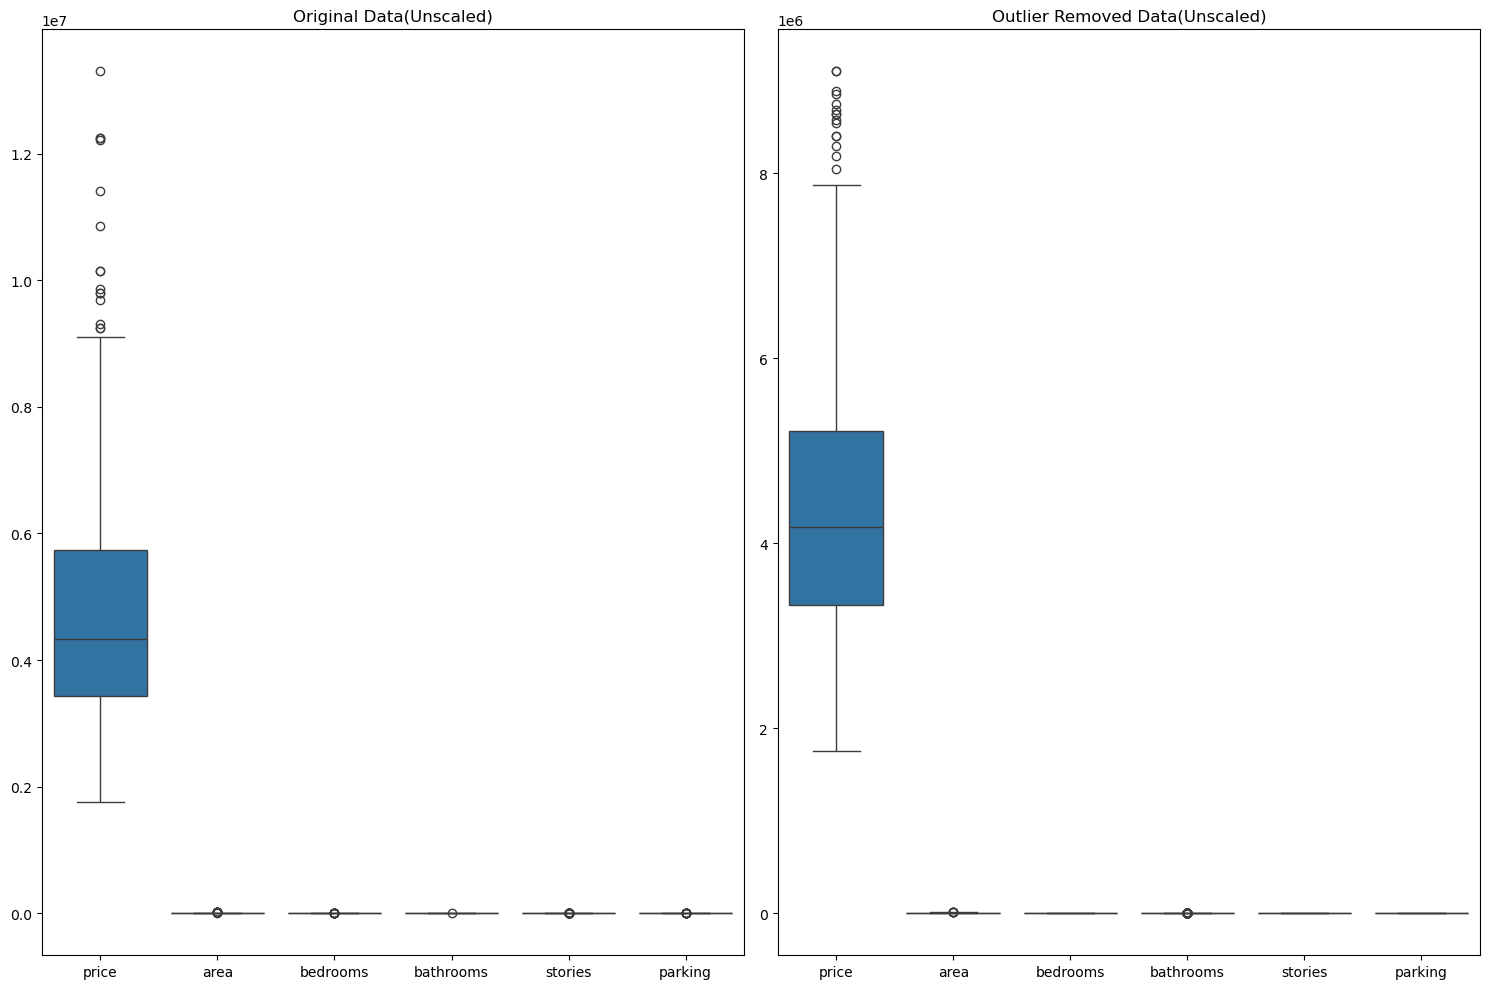

In [9]:
fig,axes = plt.subplots(1,2,figsize=(15, 10))

sns.boxplot(df,ax=axes[0])
axes[0].set_title("Original Data(Unscaled)")

sns.boxplot(df2,ax=axes[1])
axes[1].set_title("Outlier Removed Data(Unscaled)")

plt.tight_layout()
plt.show()

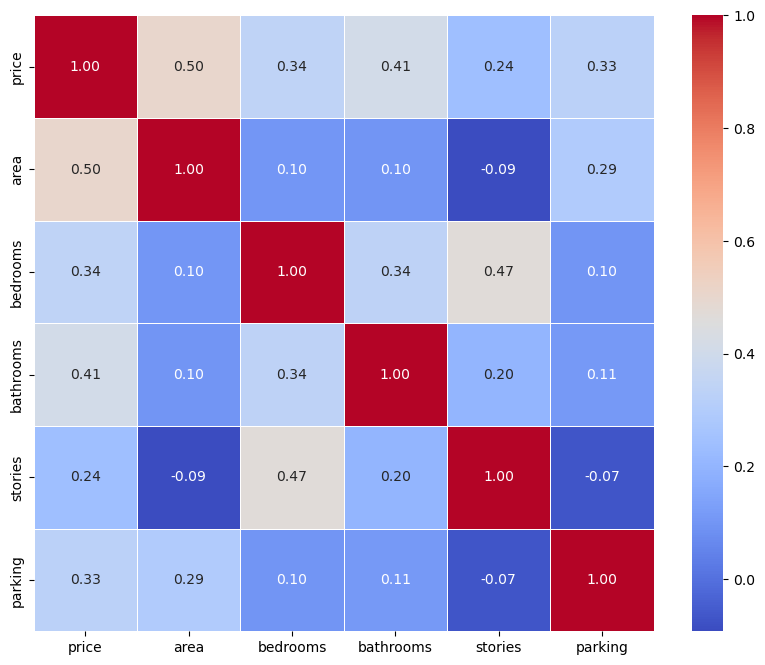

In [10]:
corr_matrix=df2.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.show()

In [11]:
X=df2[['area','bathrooms','bedrooms']].values
y=df2['price'].values

In [12]:
print('Feature matrix:\n',X.shape)

Feature matrix:
 (460, 3)


In [13]:
print('Target vector:\n',y.shape)

Target vector:
 (460,)


In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size = 0.2)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train) 
X_test=scaler.transform(X_test)

In [16]:
intercept=np.ones((X_train.shape[0],1))
X_train=np.concatenate((intercept,X_train),axis=1)

intercept=np.ones((X_test.shape[0],1))
X_test=np.concatenate((intercept, X_test),axis=1)

In [17]:
def mse(yhat,y):
   return ((yhat-y)**2).sum()/yhat.shape[0]

In [18]:
from time import time

theta=np.zeros(X_train.shape[1])
alpha=0.0001
max_iteration=50

start=time()
cost_history=[]
for i in range(max_iteration):
    y_hat=X_train@theta
    grad=X_train.T@(y_hat-y_train)
    theta=theta-alpha*grad
    cost=mse(y_hat,y_train)
    cost_history.append(cost)
    
time_taken=time()-start

print("Time taken:",time_taken)
print("Theta:",theta)

Time taken: 0.0008871555328369141
Theta: [3686759.21539085  595086.58730858  408683.64101088  270023.252394  ]


In [19]:
yhat_train=X_train@theta
mse_train=mse(yhat_train,y_train)
print("MSE train:",mse_train)

yhat_test=X_test@theta
mse_test=mse(yhat_test,y_test)
print("MSE test:",mse_test)

MSE train: 1680025047388.3796
MSE test: 1908154926877.0503


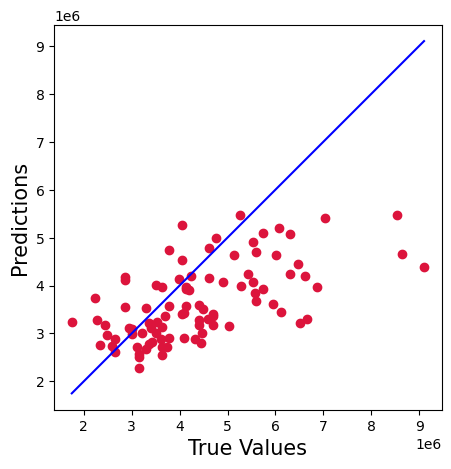

In [20]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, yhat_test,c='crimson')

p1=max(max(yhat_test),max(y_test))
p2=min(min(yhat_test), min(y_test))
plt.plot([p1,p2],[p1,p2],'b-')
plt.xlabel('True Values',fontsize=15)
plt.ylabel('Predictions',fontsize=15)
plt.axis('equal')
plt.show()

In [21]:
print('Sample value test -->',X_test[0]@theta)
print('predicted value -->',y_test[0])

Sample value test --> 3085454.0710993605
predicted value --> 3010000


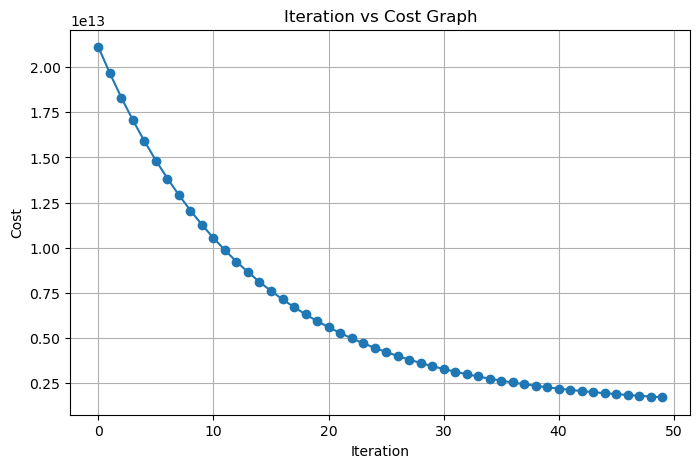

In [23]:
plt.figure(figsize=(8,5))
plt.plot(range(max_iteration),cost_history,marker='o',linestyle='-')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Iteration vs Cost Graph')
plt.grid()
plt.show()